## Load and Preprocess Dataset

In this step, we load the MNIST dataset, normalize the pixel values to the range [0,1], and reshape the images to make them compatible with convolutional layers.

In [1]:
from tensorflow.keras.datasets import mnist
import numpy as np

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


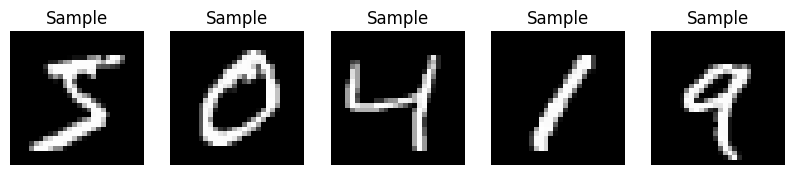

In [2]:
# Visualize sample images

import matplotlib.pyplot as plt

n = 5
plt.figure(figsize=(10,2))

for i in range(n):
    ax = plt.subplot(1, n, i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title("Sample")
    plt.axis('off')

plt.show()

## Adding Noise to Images

In this step, we add Gaussian noise to the images to simulate corrupted data.
The autoencoder will learn to remove this noise and reconstruct the original image.

Noise factor controls how much noise is added.

In [3]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values to keep them between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noisy data created")

Noisy data created


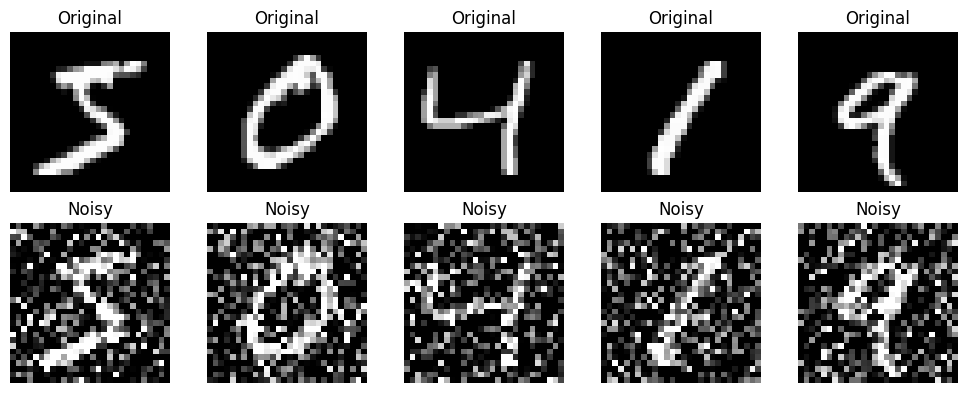

In [4]:
# Visualizing the Original content vs Noisy ones

n = 5
plt.figure(figsize=(10,4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.tight_layout()
plt.show()

##Building Denoising Autoencoder

In [6]:
# Import required layers
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# ---------- ENCODER ----------
input_img = Input(shape=(28, 28, 1))

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# ---------- DECODER ----------
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# ---------- AUTOENCODER ----------
autoencoder = Model(input_img, decoded)

# Compile model
autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

# Show summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 4: Train the Autoencoder

In this step, we train the autoencoder using noisy images as input and clean images as the target.

The model learns to reconstruct clean images from noisy inputs by minimizing the reconstruction loss.

In [7]:
# Train the autoencoder

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 170s 358ms/step - loss: 0.1501 - val_loss: 0.1115
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 172s 368ms/step - loss: 0.1081 - val_loss: 0.1039
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 165s 351ms/step - loss: 0.1035 - val_loss: 0.1014
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 346ms/step - loss: 0.1013 - val_loss: 0.0995
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 159s 338ms/step - loss: 0.0997 - val_loss: 0.0985
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 158s 337ms/step - loss: 0.0986 - val_loss: 0.0973
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 164s 350ms/step - loss: 0.0978 - val_loss: 0.0968
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 341ms/step - loss: 0.0971 - val_loss: 0.0961
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 161s 344ms/step - loss: 0.0965 - val_loss: 0.0958
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 161s 342ms/step - loss: 0.0960 - val_loss: 0.0953


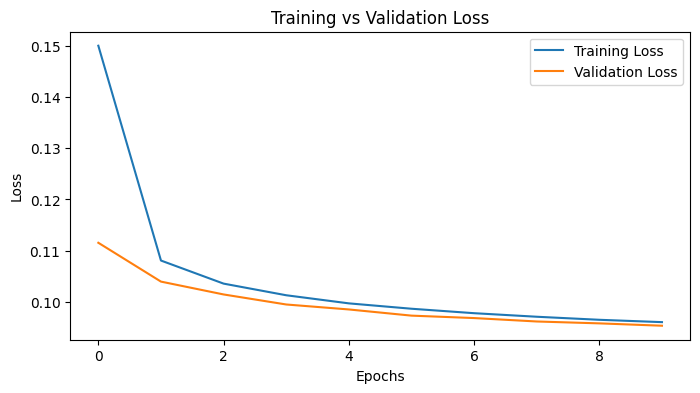

In [8]:
# Plot training and validation loss

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

##Evaluate the Autoencoder

In this step, we evaluate the performance of the autoencoder

In [9]:
# Generate denoised images

denoised_images = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


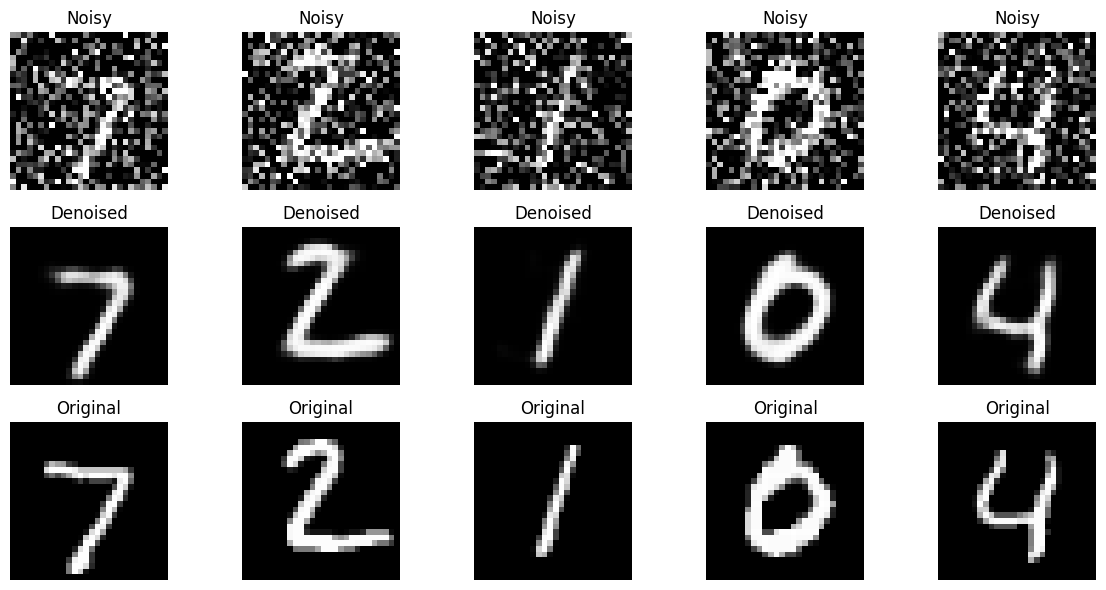

Text(0.5, 0.98, 'Noisy → Denoised → Original Comparison')

<Figure size 640x480 with 0 Axes>

In [10]:
# Visualize Noisy → Denoised → Clean

n = 5
plt.figure(figsize=(12,6))

for i in range(n):

    # Noisy Image
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised Image
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(denoised_images[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # Original Image
    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.tight_layout()
plt.show()
plt.suptitle("Noisy → Denoised → Original Comparison", fontsize=14)